# 302.4. Faint proper motion source selection

<div style="max-width:300px; float: left; margin-right: 1em">

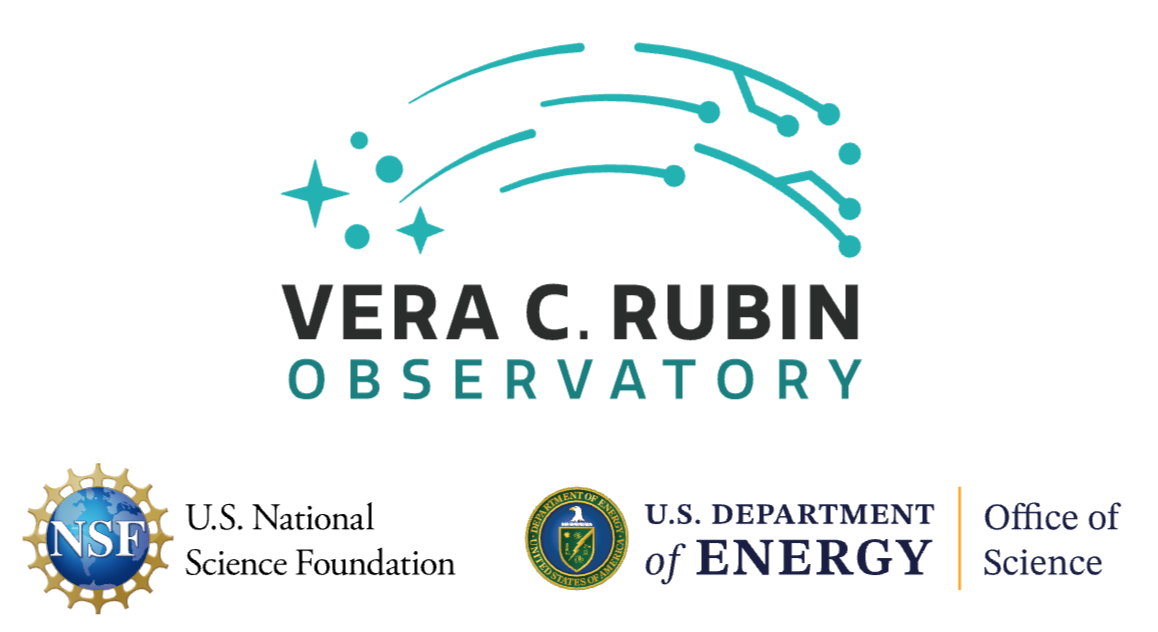

</div>

For the Rubin Science Platform at data.lsst.cloud.\
Data Release: [Data Preview 2](https://dp2.lsst.io)\
Container Size: Large\
LSST Science Pipelines version: r30.0.11\
Last verified to run: 2026-10-05\
Repository: [github.com/lsst/tutorial-notebooks](https://github.com/lsst/tutorial-notebooks)\
DOI: [10.11578/rubin/dc.20250909.20](https://doi.org/10.11578/rubin/dc.20250909.20)

**Learning objective:** Use the `IsolatedStarStellarMotions` table to help identify high proper motion sources beyond Gaia's depth.

**LSST data products:** `IsolatedStarStellarMotions`

**Packages:** `lsst.rsp.get_tap_service`

**Credit:** Originally developed by the Rubin Community Science team. Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks. The NOIRLab Source Catalog is described in [Nidever et al. 2018.](https://iopscience.iop.org/article/10.3847/1538-3881/aad68f) and [Nidever et al. 2021](https://iopscience.iop.org/article/10.3847/1538-3881/abd6e1). This research used services or data provided by the Astro Data Lab, which is part of the Community Science and Data Center (CSDC) Program of NSF NOIRLab ([Fitzpatrick et al. 2014](https://doi.org/10.1117/12.2057445); [Nikutta et al. 2020](https://doi.org/10.1016/j.ascom.2020.100411)). NOIRLab is operated by the Association of Universities for Research in Astronomy (AURA), Inc. under a cooperative agreement with the U.S. National Science Foundation.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the [Support Category](https://community.lsst.org/c/support) of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

The `IsolatedStarStellarMotions` table provides Rubin-based proper motion measurements for hundreds of millions of isolated stars. Gaia proper motion solutions are used as priors where available. For relatively faint stars detected by Rubin, Gaia does not provide proper motion solutions. This notebook shows an example of using the `IsolatedStarStellarMotions` table to identify faint high proper motion sources that lack Gaia proper motion solutions. This notebook focuses on the ELAIS S1 deep drilling field, which provides a footprint with hundreds of overlapping LSSTCam exposures that span a ~200 day time baseline in DP2.

Searches for rare astronomical objects like high proper motion stars inherently select outliers in the catalog, and therefore generally suffer from high false positive rates due to noise excursions and artifacts which are rare but may be less rare than the targets of interest. To assemble a bona-fide sample of high proper motion objects in the ELAIS S1 field, this notebook begins with a large, unvetted sample of high proper motion candidates selected from NOIRLab Source Catalog (NSC) Data Release 2 (DR2), based on Dark Energy Camera (DECam) observations of this field during the 2010's. This initial, unvetted list of candidates, which contains many false positives, is then cross-referenced with high proper motion objects selected from the Rubin DP2 `IsolatedStarStellarMotions` table to create a pure sample of bona-fide high proper motion objects in the ELAIS S1 field that are too faint to have Gaia proper motion measurements. The cross-match between `IsolatedStarStellarMotions` and NSC makes it possible to confirm the high proper motions reported by the `IsolatedStarStellarMotions` table and by NSC, in the absence of available proper motions from Gaia. The purity of the sample for which DP2 and NSC agree on each source's high proper motions is achieved thanks to the fact that, while both DP2 and NSC have noise and artifacts, the noise and artifacts are generally uncorrelated in these two independent datasets.

### 1.1. Import packages

Import `numpy`, a fundamental package for scientific computing with arrays in Python
([numpy.org](https://numpy.org)), and
`matplotlib`, a comprehensive library for data visualization
([matplotlib.org](https://matplotlib.org/); [matplotlib gallery](https://matplotlib.org/stable/gallery/index.html)). From the `lsst` package, import a utility for accessing the Table Access Protocol (TAP) service.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from lsst.rsp import get_tap_service
import astropy.io.fits as fits
from astropy.time import Time

### 1.2. Define parameters and functions

Define parameters to use colorblind-friendly colors with `matplotlib`.

In [ ]:
plt.style.use('seaborn-v0_8-colorblind')
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

Get an instance of the TAP service, and assert that it exists.

In [ ]:
service = get_tap_service("tap")
assert service is not None

## 2. Load a table of unvetted candidate high proper motion objects

The initial list of several thousand unvetted high proper motion candidates in the ELAIS S1 field was obtained by querying the NOIRLab Source Catalog via NOIRLab's [Astro Data Lab](https://datalab.noirlab.edu/). This list of unvetted NSC candidates includes legitimate high proper motion stars mixed with contaminants due to artifacts and noise. The NSC list of high proper motion candidates was selected from the NSC DR2 `Object` table according to the following criteria:

- within 1.1° of (RA, Dec) = (9.5°, -44°)
- at least 8 detections by NSC in individual exposures
- no Gaia DR3 source with proper motions available within 3$''$
- total proper motion > 50 mas/yr, where total proper motion is defined as $\mu = \sqrt{\mu^2_{\alpha} + \mu^2_{\delta}}$
- significance of motion > 30, where significance of motion is defined as $X^2_{\rm motion} = (\mu_{\alpha}/\sigma_{\mu_{\alpha}})^2 + (\mu_{\delta}/\sigma_{\mu_{\delta}})^2$
- time baseline of NSC detections for the object is > 1000 days

Note that additional NSC cuts may be possible, for instance on its `flags` column, however this notebook instead illustrates a filtering method that relies on cross-referencing high proper motions from NSC with those from the Rubin DP2 `IsolatedStarStellarMotions` catalog.

Read in the unvetted list of NSC high proper motion candidates in ELAIS S1:

In [ ]:
path = '/rubin/cst_repos/tutorial-notebooks-data/data/'
nsc_hpm_candidates = Table.read(path + 'dp2_302_4_NSC_candidates.csv')

Print the number of NSC high proper motion candidates in ELAIS S1:

In [ ]:
len(nsc_hpm_candidates)

The NSC proper motion selection includes false positives, and the goal is to use the Rubin DP2 `IsolatedStarStellarMotions` table in combination with NSC DR2 to isolate a pure sample of high proper motion objects. Figure 1 illustrates that the images used to create both NSC (DECam images) and DP2's `IsolatedStarStellarMotions` (LSSTCam images) both have artifacts like diffraction spikes, but these artifacts are poorly correlated, allowing for selection of a pure sample whose members have high proper motions reported in _both_ DP2 and NSC.

<div style="max-width:600px">
    
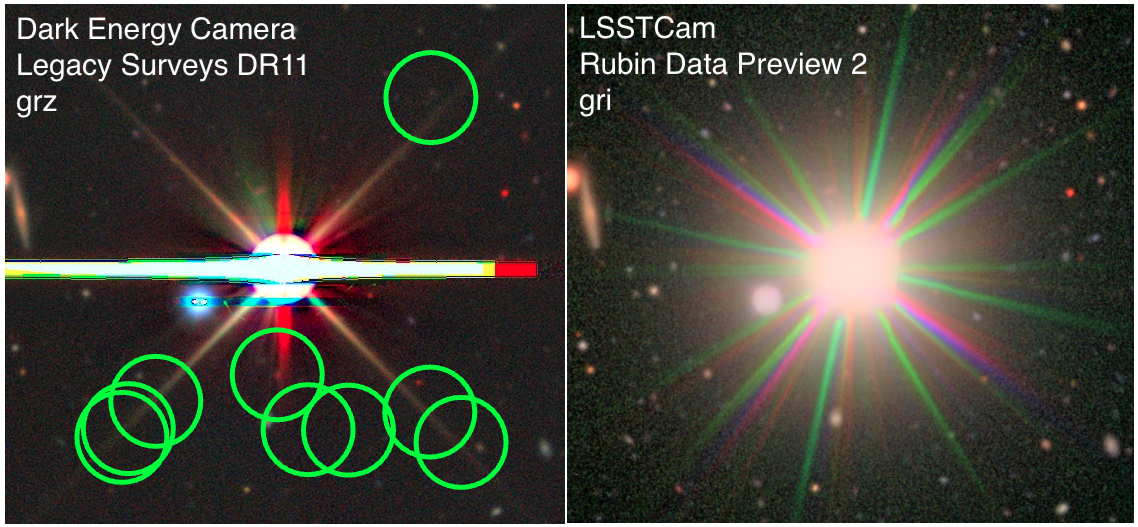

</div>

> Figure 1: Left $-$ NSC high proper motion selection contaminants (at centers of green circles) related to a bright star in the ELAIS S1 deep drilling field. The background image is a Dark Energy Camera (DECam) color composite from DESI Legacy Surveys DR11 ([Dey et al. 2019](https://ui.adsabs.harvard.edu/abs/2019AJ....157..168D/abstract); [legacysurvey.org/viewer](http://legacysurvey.org/viewer)). Right $-$ DP2 gri 'pretty coadd' of the same sky region, showing that artifacts like diffraction spikes, while present in both datasets, are poorly correlated, allowing for a pure sample to be selected by requiring high proper motion to be reported in both DP2 and NSC. Each cutout is approximately 1.9$'$ on a side.

## 3. Cross-match to `IsolatedStarStellarMotions`

Spatially cross-match the table of NSC high proper motion candidates to the DP2 `IsolatedStarStellarMotions` table with a 3$''$ matching radius. The query defined below makes use of user-uploaded table functionality available from TAP.

In [ ]:
query = "SELECT "\
        "istar.ra, istar.dec, istar.referenceId, "\
        "istar.epoch, istar.rapm, istar.rapmerr, "\
        "istar.decpm, istar.decpmerr, "\
        "nsc.pmra AS nsc_rapm, "\
        "nsc.pmdec AS nsc_decpm, nsc.mjd as nsc_mjd, "\
        "nsc.ra AS nsc_ra, nsc.dec as nsc_dec, "\
        "nsc.pmraerr AS nsc_rapmerr, nsc.pmdecerr as nsc_decpmerr "\
        "FROM dp2.IsolatedStarStellarMotions AS istar "\
        "JOIN TAP_UPLOAD.ut1 AS nsc "\
        "WHERE CONTAINS(POINT('ICRS', istar.ra, istar.dec), "\
        "CIRCLE('ICRS', nsc.ra, nsc.dec, 0.00083))=1 "

Run the query. Note how the `nsc_hpm_candidates` table is passed via the `uploads` keyword argument as a user-uploaded table.

In [ ]:
job = service.submit_job(query, uploads={"ut1": nsc_hpm_candidates})
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()

Assert that the job completed and retrieve the results as an astropy Table.

In [ ]:
assert job.phase == 'COMPLETED'
results = job.fetch_result().to_table()

The results table includes columns from both the `IsolatedStarStellarMotions` table and from the user-uploaded table of NSC candidates. Add two more columns, computed based on the `IsolatedStarStellarMotions` columns retrieved via the TAP query:

- `pmtot`, given by $\mu = \sqrt{\mu^2_{\alpha} + \mu^2_{\delta}}$, where within the `IsolatedStarStellarMotions` table $\mu_{\alpha}$ is column `rapm` and $\mu_{\delta}$ is column `decpm`
- `chi2_motion`, defined as $X^2_{\rm motion} = (\mu_{\alpha}/\sigma_{\mu_{\alpha}})^2 + (\mu_{\delta}/\sigma_{\mu_{\delta}})^2$, where within the `IsolatedStarStellarMotions` table $\sigma_{\mu_{\alpha}}$ is column `rapmerr` and $\sigma_{\mu_{\delta}}$ is column `decpmerr`.

In [ ]:
results['pmtot'] = np.sqrt(np.power(results['rapm'], 2) + np.power(results['decpm'], 2))
results['chi2_motion'] = np.power(results['rapm']/results['rapmerr'], 2) + np.power(results['decpm']/results['decpmerr'], 2)

Downselect to those NSC high proper motion candidates that also have high proper motion (> 50 mas/yr) and high significance of motion ($X^2_{\rm motion} > 30$) in DP2's `IsolatedStarStellarMotions` catalog.

In [ ]:
true_hpm = (results['pmtot'] > 50) & (results['referenceId'] == 0) & (results['chi2_motion'] > 30)
results = results[true_hpm]

For the sample of confirmed high proper motion objects, compare the proper motions from DP2's `IsolatedStarStellarMotions` and NSC, to show that they are similar.

In [ ]:
plt.figure(figsize=(10,3))

plt.subplot(1, 2, 1)
plt.errorbar(results['rapm'], results['nsc_rapm'], xerr=results['rapmerr'], yerr=results['nsc_rapmerr'], fmt='o', markersize=3)
plt.plot([-150, 250], [-150, 250], c='r', linewidth=0.5)
plt.xlabel('DP2 rapm (mas/yr)')
plt.ylabel('NSC rapm (mas/yr)')

plt.subplot(1, 2, 2)
plt.errorbar(results['decpm'], results['nsc_decpm'], xerr=results['decpmerr'], yerr=results['nsc_decpmerr'], fmt='o', markersize=3)
plt.plot([-100, 100], [-100, 100], c='r', linewidth=0.5)
plt.xlabel('DP2 decpm (mas/yr)')
plt.ylabel('NSC decpm (mas/yr)')

> Figure 2: Agreement between Rubin DP2 `IsolatedStarStellarMotions` proper motion components and those of NSC DR2 (`rapm` at left, `decpm` at right), for the identified set of bona-fide high proper motion objects. The red line in each panel denotes the locus of 1-to-1 agreement between `IsolatedStarStellarMotions` and NSC.

## 3. Further confirm the proper motions

Compare the Rubin DP2 `IsolatedStarStellarMotions` reference epoch position to the NSC mean epoch position for each high proper motion object to further confirm that these DP2-NSC positional offsets are consistent with the proper motions reported in the `IsolatedStarStellarMotions` table.

In [ ]:
ref_epoch_istar = Time(results['epoch'], format='mjd').decimalyear
mean_epoch_nsc = Time(results['nsc_mjd'], format='mjd').decimalyear

rapm_dp2_nsc = (results['ra'] - results['nsc_ra'])*3600.0*1000.0*np.cos(np.radians(results['dec']))/(ref_epoch_istar - mean_epoch_nsc)
decpm_dp2_nsc = (results['dec'] - results['nsc_dec'])*3600.0*1000.0/(ref_epoch_istar - mean_epoch_nsc)

Having computed proper motions from the difference between each object's position at the `IsolatedStarStellarMotions` reference epoch versus the NSC mean epoch, make a scatter plot showing that these newly computed DP2-NSC proper motions are consistent with the `IsolatedStarStellarMotions` proper motions.

In [ ]:
plt.figure(figsize=(10,3))

plt.subplot(1, 2, 1)
plt.errorbar(results['rapm'], rapm_dp2_nsc, xerr=results['rapmerr'], fmt='o', markersize=3)
plt.plot([-50,280], [-50,280], linewidth=0.5, c='r')
plt.xlabel('DP2 rapm (mas/yr)')
plt.ylabel('joint DP2+NSC RA PM')

plt.subplot(1, 2, 2)
plt.errorbar(results['decpm'], decpm_dp2_nsc, xerr=results['decpmerr'], fmt='o', markersize=3)
plt.plot([-100,50], [-100,50], linewidth=0.5, c='r')
plt.xlabel('DP2 decpm (mas/yr)')
plt.ylabel('joint DP2+NSC Dec PM')

> Figure 3: Agreement between Rubin DP2 `IsolatedStarStellarMotions` proper motion components and proper motion components computed by leveraging the ~10 year time baseline between DP2 and NSC to compute proper motions from the difference between each object's mean coordinates in DP2 versus NSC. The left panel shows the `rapm` proper motion component and the right panel shows the `decpm` proper motion component. The red line in each panel denotes the locus of 1-to-1 agreement between `IsolatedStarStellarMotions` and NSC.

## 4. Examine the distribution of total proper motions

Examine the distribution of total proper motion values ($\mu = \sqrt{\mu^2_{\alpha} + \mu^2_{\delta}}$) for the bona-fide sample of high proper motion objects selected from within ELAIS S1. Plot a histogram of the total proper motion values and print out the median total proper motion value.

In [ ]:
plt.hist(results['pmtot'], bins=np.arange(50, 290, 20))
plt.xlabel('IsolatedStarStellarMotions total proper motion (mas/yr)')
plt.ylabel('stars per bin')
plt.title(str(len(results)) + ' bona-fide faint high proper motion stars in ELAIS S1')

pmtot_median = np.ma.median(results['pmtot'])
print('median total proper motion among bona-fide high proper motion sample members = {:.1f} mas/yr'.format(pmtot_median))

> Figure 4: Histogram of total proper motions for the pure sample of faint high proper motion objects in ELAIS S1.